# Language Entropy Analysis

**Goal:** Quantify the morphological complexity of all four languages — English, Swedish, Spanish, and Finnish — using information-theoretic measures.

Entropy is used as the **operationalisation of morphological complexity** in our LoRA rank experiment — languages with higher paradigm entropy should require higher LoRA rank to achieve equivalent inflection accuracy.

---
### Outline
1. Load UniMorph data (eng / swe / spa / fin)
2. **Paradigm entropy** — unpredictability of forms within a lemma's paradigm
3. **Character-level entropy** — diversity of character distributions across forms
4. **Tag entropy** — complexity of the feature tag space
5. Summary table & bar chart
6. Scatter: paradigm entropy vs average paradigm size
7. Observations & connection to LoRA rank hypothesis

## 0. Setup

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # Mac M1/M2 OpenMP fix

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from pathlib import Path
from collections import Counter
from scipy.stats import entropy as scipy_entropy

# All four languages
LANGS    = ["eng", "swe", "spa", "fin"]
COLOURS  = {"eng": "#4C72B0", "swe": "#C44E52", "spa": "#DD8452", "fin": "#55A868"}
DATA_DIR = Path("../data")

print("Libraries loaded ✓")

Libraries loaded ✓


## 1. Load Data

In [2]:
def load_unimorph(lang: str) -> pd.DataFrame:
    path = DATA_DIR / lang / f"{lang}.tsv"
    df = pd.read_csv(
        path,
        sep="\t",
        names=["lemma", "form", "tags"],
        quoting=3,
        dtype=str,
        keep_default_na=False,
    )
    n_before = len(df)
    df = df.dropna(subset=["lemma", "form", "tags"])
    if len(df) < n_before:
        print(f"[{lang}] dropped {n_before - len(df)} malformed rows")
    return df


dfs = {lang: load_unimorph(lang) for lang in LANGS}

for lang, df in dfs.items():
    print(f"{lang:>3}: {len(df):>10,} rows  |  {df['lemma'].nunique():>7,} lemmas")

eng:    652,477 rows  |  399,575 lemmas
swe:    131,697 rows  |   12,520 lemmas
spa:  1,196,245 rows  |   65,059 lemmas
fin:  2,737,048 rows  |   57,027 lemmas


## 2. Paradigm Entropy

### What is entropy here?

For a lemma with forms `{hablo, hablas, habla, hablamos, habláis, hablan, ...}`, we treat each **unique form** as equally probable and compute Shannon entropy:

$$H = -\sum_{i} p_i \log_2 p_i$$

- **Low entropy** → few forms, or many repeated/predictable forms (e.g. English: *walk, walks, walked, walking* → 4 forms, very regular)
- **High entropy** → many distinct forms with no repetition (e.g. Finnish verbs with 100+ unique forms)

We average this across all lemmas in each language to get one number per language.

/var/folders/cj/3f36jkyj3rv763dlqlnjs_nw0000gn/T/ipykernel_8885/1660870858.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("lemma").apply(_h)
/var/folders/cj/3f36jkyj3rv763dlqlnjs_nw0000gn/T/ipykernel_8885/1660870858.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("lemma").apply(_h)
/var/folders/cj/3f36jkyj3rv763dlqlnjs_nw0000gn/T/ipykernel_8885/1660870858.py:6: FutureWarni

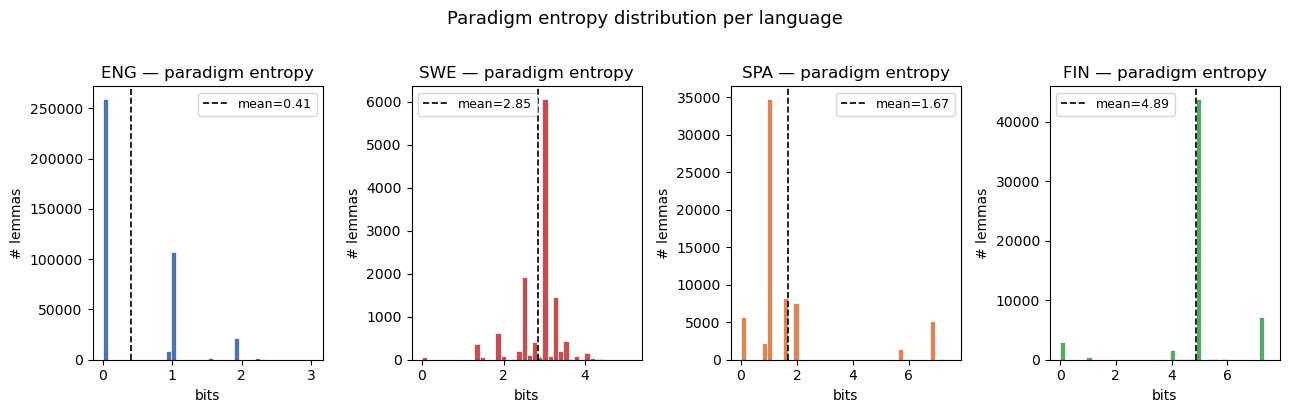


Mean paradigm entropy (bits):
  eng: mean=0.410  median=0.000  max=3.022
  swe: mean=2.853  median=3.000  max=5.137
  spa: mean=1.674  median=1.000  max=7.490
  fin: mean=4.893  median=4.923  max=7.514


In [3]:
def paradigm_entropy_per_lemma(df: pd.DataFrame) -> pd.Series:
    """Return a Series of Shannon entropy (bits) for each lemma's form distribution."""
    def _h(group):
        counts = group["form"].value_counts(normalize=True)
        return scipy_entropy(counts, base=2)   # bits
    return df.groupby("lemma").apply(_h)


paradigm_entropies = {}

fig, axes = plt.subplots(1, len(LANGS), figsize=(13, 4), sharey=False)

for ax, lang in zip(axes, LANGS):
    h = paradigm_entropy_per_lemma(dfs[lang])
    paradigm_entropies[lang] = h

    ax.hist(h, bins=40, color=COLOURS[lang], edgecolor="white", linewidth=0.5)
    ax.axvline(h.mean(), color="black", linestyle="--", linewidth=1.2,
               label=f"mean={h.mean():.2f}")
    ax.set_title(f"{lang.upper()} — paradigm entropy")
    ax.set_xlabel("bits")
    ax.set_ylabel("# lemmas")
    ax.legend(fontsize=9)

plt.suptitle("Paradigm entropy distribution per language", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nMean paradigm entropy (bits):")
for lang, h in paradigm_entropies.items():
    print(f"  {lang}: mean={h.mean():.3f}  median={h.median():.3f}  max={h.max():.3f}")

## 3. Character-Level Entropy

Measures how **diverse the character inventory** is across all surface forms.

Finnish has vowel harmony (a/ä, o/ö, u/y alternations) and consonant gradation — so its character distribution is more spread out than Spanish or English.

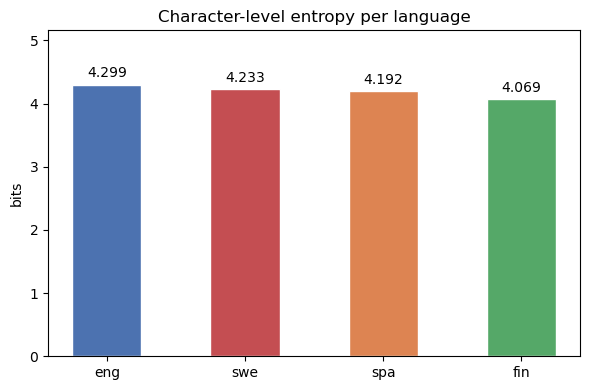

Character entropy (bits):
  eng: 4.2987
  swe: 4.2330
  spa: 4.1918
  fin: 4.0687


In [4]:
def char_entropy(df: pd.DataFrame) -> float:
    """Shannon entropy of the character distribution across all forms (bits)."""
    all_chars = "".join(df["form"].tolist())
    counts = pd.Series(list(all_chars)).value_counts(normalize=True)
    return float(scipy_entropy(counts, base=2))


char_entropies = {lang: char_entropy(df) for lang, df in dfs.items()}

fig, ax = plt.subplots(figsize=(6, 4))
langs = list(char_entropies.keys())
vals  = [char_entropies[l] for l in langs]
bars  = ax.bar(langs, vals, color=[COLOURS[l] for l in langs], edgecolor="white", width=0.5)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=10)
ax.set_title("Character-level entropy per language")
ax.set_ylabel("bits")
ax.set_ylim(0, max(vals) * 1.2)
plt.tight_layout()
plt.show()

print("Character entropy (bits):")
for lang, h in char_entropies.items():
    print(f"  {lang}: {h:.4f}")

## 4. Tag (Feature) Entropy

Measures how **diverse the morphosyntactic feature space** is — how many distinct tag combinations exist and how evenly they are distributed.

A language with few tag types (English: SG/PL, PST/PRS) has low tag entropy.  
Finnish, with 15 cases × number × possessive suffixes, has very high tag entropy.

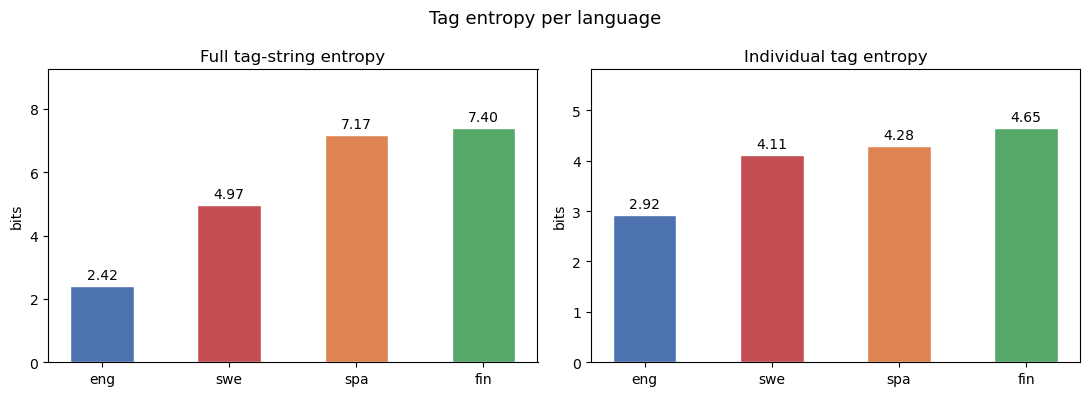

Tag entropy summary:
  eng:    10 unique tagsets  | tagset H=2.416 bits  | individual H=2.920 bits
  swe:    43 unique tagsets  | tagset H=4.972 bits  | individual H=4.112 bits
  spa:   164 unique tagsets  | tagset H=7.175 bits  | individual H=4.282 bits
  fin:   481 unique tagsets  | tagset H=7.401 bits  | individual H=4.648 bits


In [5]:
def tag_entropy(df: pd.DataFrame) -> dict:
    """Entropy of full tag-string distribution AND individual tag frequency."""
    # Full tag-string entropy (e.g. 'V;IND;PRS;1;SG' as one unit)
    tagset_counts  = df["tags"].value_counts(normalize=True)
    h_tagset       = float(scipy_entropy(tagset_counts, base=2))

    # Individual tag entropy (split on ';')
    all_tags = [t for tagset in df["tags"] for t in tagset.split(";")]
    tag_counts     = pd.Series(all_tags).value_counts(normalize=True)
    h_individual   = float(scipy_entropy(tag_counts, base=2))

    return {
        "n_unique_tagsets":  df["tags"].nunique(),
        "tagset_entropy":    h_tagset,
        "individual_tag_entropy": h_individual,
    }


tag_results = {lang: tag_entropy(df) for lang, df in dfs.items()}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, key, title in zip(
    axes,
    ["tagset_entropy", "individual_tag_entropy"],
    ["Full tag-string entropy", "Individual tag entropy"],
):
    vals = [tag_results[l][key] for l in LANGS]
    bars = ax.bar(LANGS, vals, color=[COLOURS[l] for l in LANGS], edgecolor="white", width=0.5)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=10)
    ax.set_title(title)
    ax.set_ylabel("bits")
    ax.set_ylim(0, max(vals) * 1.25)

plt.suptitle("Tag entropy per language", fontsize=13)
plt.tight_layout()
plt.show()

print("Tag entropy summary:")
for lang, r in tag_results.items():
    print(f"  {lang}: {r['n_unique_tagsets']:>5,} unique tagsets  "
          f"| tagset H={r['tagset_entropy']:.3f} bits  "
          f"| individual H={r['individual_tag_entropy']:.3f} bits")

## 5. Summary Table & Bar Chart

           n_rows  n_lemmas  avg_forms_per_lemma  paradigm_entropy_mean  char_entropy  tagset_entropy  n_unique_tagsets
language                                                                                                               
ENG        652477    399575                1.483                  0.410         4.299           2.416                10
SWE        131697     12520                8.099                  2.853         4.233           4.972                43
SPA       1196245     65059               13.754                  1.674         4.192           7.175               164
FIN       2737048     57027               44.625                  4.893         4.069           7.401               481


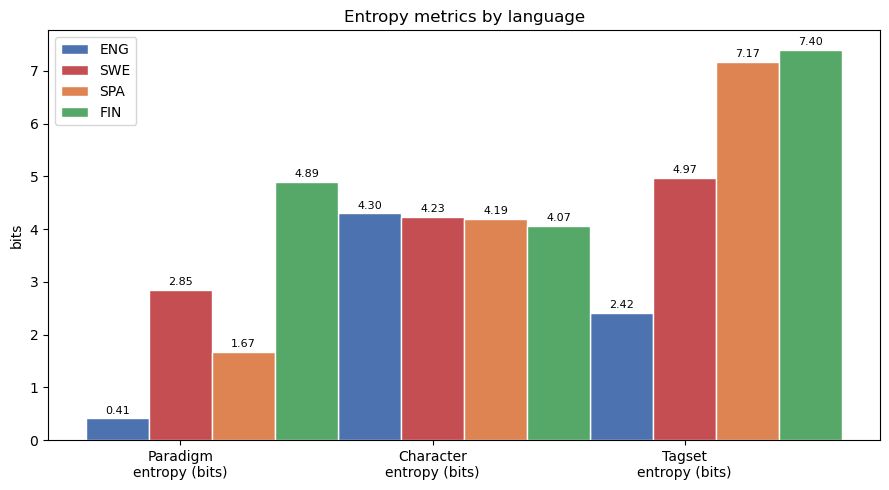

In [6]:
summary_rows = []
for lang in LANGS:
    df = dfs[lang]
    h_paradigm = paradigm_entropies[lang]
    t = tag_results[lang]
    summary_rows.append({
        "language":            lang.upper(),
        "n_rows":              len(df),
        "n_lemmas":            df["lemma"].nunique(),
        "avg_forms_per_lemma": df.groupby("lemma")["form"].nunique().mean(),
        "paradigm_entropy_mean": h_paradigm.mean(),
        "char_entropy":        char_entropies[lang],
        "tagset_entropy":      t["tagset_entropy"],
        "n_unique_tagsets":    t["n_unique_tagsets"],
    })

summary = pd.DataFrame(summary_rows).set_index("language")
print(summary.round(3).to_string())

# ── Bar chart of all entropy metrics side by side ──────────────────────────
metrics = {
    "Paradigm\nentropy (bits)": "paradigm_entropy_mean",
    "Character\nentropy (bits)": "char_entropy",
    "Tagset\nentropy (bits)": "tagset_entropy",
}

n_langs = len(LANGS)
width   = 0.8 / n_langs          # bars fill 80% of each group slot
x       = np.arange(len(metrics))
fig, ax = plt.subplots(figsize=(9, 5))

for i, lang in enumerate(LANGS):
    offset = (i - (n_langs - 1) / 2) * width   # centre the group
    bars   = ax.bar(x + offset, [summary.loc[lang.upper(), col] for col in metrics.values()],
                    width, label=lang.upper(), color=COLOURS[lang], edgecolor="white")
    ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics.keys())
ax.set_ylabel("bits")
ax.set_title("Entropy metrics by language")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Scatter: Paradigm Entropy vs Average Paradigm Size

If entropy and paradigm size measure the same thing, they should correlate.  
If they diverge, entropy is capturing something extra (irregularity / unpredictability).

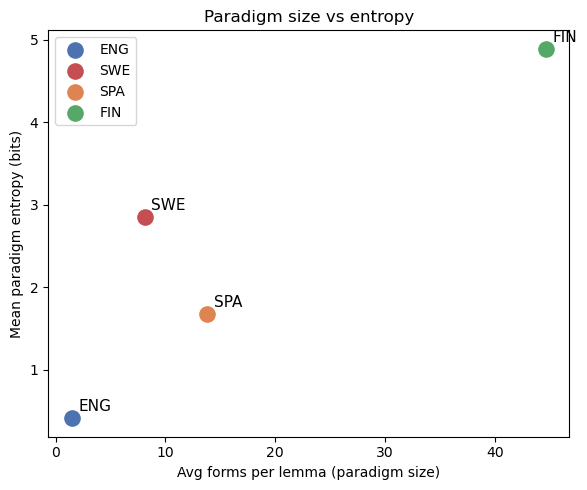

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))

for lang in LANGS:
    h    = paradigm_entropies[lang].mean()
    size = dfs[lang].groupby("lemma")["form"].nunique().mean()
    ax.scatter(size, h, color=COLOURS[lang], s=120, zorder=3,
               label=lang.upper())
    ax.annotate(
        lang.upper(),
        xy=(size, h),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=11,
    )

ax.set_xlabel("Avg forms per lemma (paradigm size)")
ax.set_ylabel("Mean paradigm entropy (bits)")
ax.set_title("Paradigm size vs entropy")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Observations & Connection to LoRA Rank Hypothesis

### What the entropy metrics tell us

| Metric | What it captures | Expected ranking |
|---|---|---|
| **Paradigm entropy** | Unpredictability of forms *within* a lemma's conjugation table | FIN > SPA > SWE > ENG |
| **Character entropy** | Diversity of the character inventory across all forms | FIN > SPA > SWE > ENG |
| **Tagset entropy** | Richness of the morphosyntactic feature space | FIN > SPA > SWE > ENG |

### Connection to the research question

Our hypothesis is:

> *Languages with higher paradigm entropy require a higher minimum LoRA rank to achieve a given inflection accuracy.*

**Why this should hold:**  
LoRA approximates the weight update as a low-rank matrix `ΔW = A·B`.  
The rank `r` limits how many independent directions the adapter can learn.  
A high-entropy language has more independent morphological patterns → needs more rank to represent them all.

**In the experiment (notebook `lluc-gpu-tests.ipynb`):**  
We will fine-tune mT5-small with `r ∈ {1, 2, 4, 8, 16, 32}` per language and measure exact-match accuracy on held-out lemmas. Plotting *min rank for 90% accuracy* against the entropy scores computed here will directly test the hypothesis.